 Spoken digit recognition with CNN (by Francisco Rogé Vallone) 



## 1. Import libraries.


In [1]:
import numpy as np
import tensorflow as tf
import sklearn as sk
import tensorflow_datasets as tfds
import librosa as lib
import matplotlib.pyplot as plt
!pip install pydub

## 2. Download and preprocess the dataset.

In [2]:
def load_data():
  data = tfds.load("spoken_digit")
  data = list(data['train'])
  labels = []
  mel_spect = []
  for k in range(len(data)):
    audio = data[k]["audio"].numpy().astype(np.float32)
    if len(audio)>8000: continue
    labels.append(data[k]["label"].numpy().astype(np.float32))
    mel_spect.append(lib.feature.melspectrogram(y=audio, sr=8000, n_fft=256, hop_length=128))

  max_duration = max(list(map(lambda n: mel_spect[n].shape[1], range(len(mel_spect)))))
  X = np.zeros([len(mel_spect),mel_spect[0].shape[0],max_duration,1])
  for k in range(len(mel_spect)):
    X[k, :mel_spect[k].shape[0], :mel_spect[k].shape[1], 0] = lib.power_to_db(mel_spect[k], ref=np.max)

  y_encoder = sk.preprocessing.OneHotEncoder(sparse=False)
  y = y_encoder.fit_transform(np.array(labels).reshape(-1,1))

  X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2)

  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

0 examples [00:00, ? examples/s]

Shuffling and writing examples to /root/tensorflow_datasets/spoken_digit/1.0.9.incomplete7E7DWN/spoken_digit-train.tfrecord


  0%|          | 0/2500 [00:00<?, ? examples/s]

Dataset spoken_digit downloaded and prepared to /root/tensorflow_datasets/spoken_digit/1.0.9. Subsequent calls will reuse this data.


## 3. Build the CNN model.

In [3]:
tf.keras.backend.clear_session()
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), strides=(1,1), input_shape=X_train.shape[1:], activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(3, 3)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), strides=(1,1), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(3, 3)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), strides=(1,1), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(3, 3)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 61, 128)      1280      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 42, 20, 128)      0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 42, 20, 128)      512       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 40, 18, 64)        73792     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 13, 6, 64)        0         
 2D)                                                             
                                                        

## 4. Train the model.

In [4]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=128, verbose=1)

Epoch 1/20
16/16 [==============================] - 52s 3s/step - loss: 2.0921 - accuracy: 0.2971 - val_loss: 9.2321 - val_accuracy: 0.0940
Epoch 2/20
16/16 [==============================] - 38s 2s/step - loss: 1.3107 - accuracy: 0.5817 - val_loss: 9.5722 - val_accuracy: 0.0940
Epoch 3/20
16/16 [==============================] - 40s 3s/step - loss: 0.9386 - accuracy: 0.7485 - val_loss: 6.3222 - val_accuracy: 0.0940
Epoch 4/20
16/16 [==============================] - 38s 2s/step - loss: 0.6798 - accuracy: 0.8472 - val_loss: 4.2382 - val_accuracy: 0.1100
Epoch 5/20
16/16 [==============================] - 38s 2s/step - loss: 0.4960 - accuracy: 0.9053 - val_loss: 2.9993 - val_accuracy: 0.1660
Epoch 6/20
16/16 [==============================] - 38s 2s/step - loss: 0.3789 - accuracy: 0.9389 - val_loss: 2.6307 - val_accuracy: 0.2620
Epoch 7/20
16/16 [==============================] - 38s 2s/step - loss: 0.2862 - accuracy: 0.9609 - val_loss: 1.8941 - val_accuracy: 0.3660
Epoch 8/20
16/16 [==

## 5. Visualize training results.

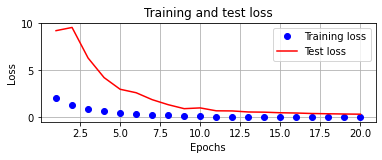

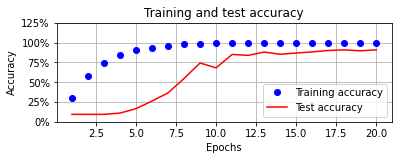

In [5]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(val_loss_values) + 1)
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'r', label='Test loss')
plt.title('Training and test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()
plt.subplot(212)
plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'r', label='Test accuracy')
plt.title('Training and test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticks(plt.gca().get_yticks())
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]) 
plt.legend()
plt.grid('off')
plt.show()